#Binary Classification with a Dense Neural Networks

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
import cupy as cp

##Dataset Preparation

I'll be using the Titanic Survival Dataset

In [ ]:
titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
df = titanic.frame

features = ['pclass', 'sex', 'age', 'fare']
target = 'survived'
df = df[features + [target]].copy()

df

,pclass,sex,age,fare,survived
0,1,female,29.0000,211.3375,1
1,1,male,0.9167,151.5500,1
2,1,female,2.0000,151.5500,0
3,1,male,30.0000,151.5500,0
4,1,female,25.0000,151.5500,0
...,...,...,...,...,...
1304,3,female,14.5000,14.4542,0
1305,3,female,NaN,14.4542,0
1306,3,male,26.5000,7.2250,0
1307,3,male,27.0000,7.2250,0


In [ ]:
df['survived'] = df['survived'].astype(int)

df['sex'] = df['sex'].map({'male': 0, 'female': 1})

#replacing NaN values with the median value of that column
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

X = df[features].to_numpy()
y = df[target].to_numpy().reshape(-1, 1)

X.shape, y.shape

((1309, 4), (1309, 1))

In [ ]:
split_ratio = 0.8
num_samples = X.shape[0]
split_index = int(num_samples * split_ratio)

np.random.seed(42)
shuffled_indices = np.random.permutation(num_samples)

X_shuffled = X[shuffled_indices]
y_shuffled = y[shuffled_indices]


X_train = X_shuffled[:split_index]
y_train = y_shuffled[:split_index]

X_val = X_shuffled[split_index:]
y_val = y_shuffled[split_index:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape

((1047, 4), (1047, 1), (262, 4), (262, 1))

In [ ]:
#z-score normalisation
tr_mean= np.mean(X_train, axis=0)
tr_std = np.std(X_train, axis=0)

tr_mean, tr_std

(array([ 2.28271251,  0.3495702 , 29.58022923, 34.24911614]),
 array([ 0.83860819,  0.47683422, 12.96319186, 54.18797857]))

In [ ]:
X_train_scaled = (X_train - tr_mean) / tr_std
X_val_scaled = (X_val - tr_mean) / tr_std
X_train_scaled.shape, y_train.shape, X_val_scaled.shape, y_val.shape

((1047, 4), (1047, 1), (262, 4), (262, 1))

In [ ]:
m= X_train_scaled.shape[0]
n= X_train_scaled.shape[1]
m, n

(1047, 4)

In [ ]:
def create_batches(X, y, batch_size):
    num_samples = X.shape[0]

    # Shuffle indices to randomize batches per epoch
    indices = np.random.permutation(num_samples)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    batches = []
    for i in range(0, num_samples, batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        batches.append((X_batch, y_batch))

    return batches

If we just keep stacking layers of neurons, it doesnt really make a difference as the final output will always be a linear function when differentiating wrt any of the variables present. In the end it would end up collapsing back into a simple linear $Wx + b$ model as covered in the previous notebook.

To break this, we add a non-linear activation function between the layers.

##Using ReLU activation

$\text{ReLU}(x) = \max(0, x)$

 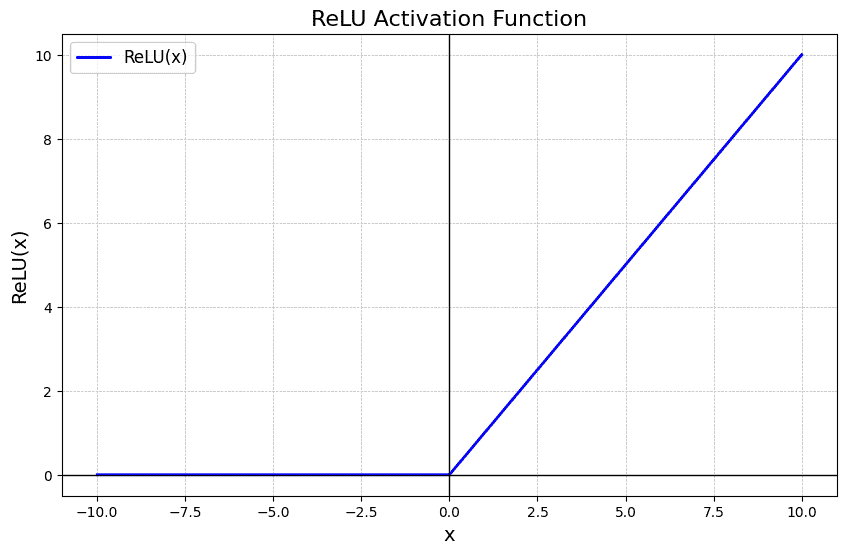

we can see the non linearity. there are also some reasons to use relu specifically like:
1. The derivative of relu is 1 for $x>0$ and 0 for $x<0$ meaning we dont have to worry about gradients exploding whenever we have to multiply its derivative
2. $\max(0, x)$ is comparitively pretty computationally inexpensive to calculate
3. Because it outputs 0 for negative outputs, this causes different portions of the neurons to be deactivated for different inputs. this saves a lot of compute
4. A fully active dense network uses all parameters to compute an output, providing too much mathematical flexibility that ends up being able to memorize random noise in the training data. By forcing a percentage of activations to $0$, relu dynamically reduces the number of active parameters for any specific input. A relatively simpler active sub-network whose configuration changes every time is inherently less capable of overfitting.

###Starting off with just one layer containing 8 neurons and no initialisation

we initially randomise the weights cz if they all were 0 then every output would be 0 as well and hence would just output the same gradient. this would break the whole point and the model would effectively just act as one giant neuron

we also multiply the weights by 0.01 to ensure that Z doesnt get too large. if it does then y_hat has a risk of getting too close to the flattened area of the sigmoid function.

In [ ]:
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

n_x = X_train_scaled.shape[1]  # number of input features
n_h = 8                        # number of neurons in the layer
n_y = 1                        # number of output neurons


np.random.seed(42)
W1 = np.random.randn(n_x, n_h) * 0.01   # (4, 8)
b1 = np.zeros((1, n_h))                 # (1, 8)

W2 = np.random.randn(n_h, n_y) * 0.01   # (8, 1)
b2 = np.zeros((1, n_y))                 # (1, 1)

def forward_propagation(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    y_hat = sigmoid(Z2)

    return {"Z1": Z1, "A1": A1, "Z2": Z2, "y_hat": y_hat}

####gradients

#####$W_2$ and $b_2$

We already know that the gradient of all the weights $W_2$ connecting the output layer is $$W_2grad = \frac{\partial L}{\partial W_2} = (\hat{y}^{\hspace{3pt}(i)} - y^{(i)})\cdot \text{input}$$

the input for the output layer is going to be the the output of our hidden layer ie $A_1$

$$\therefore W_2grad = (\hat{y}^{\hspace{3pt}(i)} - y^{(i)})\cdot A_1$$

we are also aware that $b_2grad = (\hat{y}^{\hspace{3pt}(i)} - y^{(i)})$

#####$W_1$ and $b_1$

$$ W_1grad = \frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial W_1}$$$$= (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot \frac{\partial}{\partial W_1} \Big( W_2 \cdot \text{ReLU}(Z_1) + b_2 \Big)$$$$= (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot W_2 \cdot \text{ReLU}'(Z_1) \cdot x$$$$= (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot W_2 \cdot \Big(\begin{cases} 0 & \text{if } Z_1 \leq 0 \\ 1 & \text{if } Z_1 > 0 \end{cases}\Big) \cdot x$$

after taking into account the alignment of the shapes to take the dot products: $$W_1grad = X^T \cdot ( ((\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot W_2^T) \ast \text{ReLU}'(Z_1) )$$

$$ b_1grad = \frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial b_1}$$
$$= (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot \frac{\partial}{\partial b_1} \Big( W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2 \Big)$$
$$= (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot W_2 \cdot \text{ReLU}'(W_1 x + b_1)$$
$$= (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot W_2 \cdot \Big(\begin{cases} 0 & \text{if } W_1 x + b_1 \leq 0 \\ 1 & \text{if } W_1 x + b_1 > 0 \end{cases}\Big)$$

i.e.
$$b_1grad = ((\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot W_2^T) \ast \text{ReLU}'(Z_1)$$

In [ ]:
def backprop(data, learning_rate,size,current_X_batch, current_y_batch):
  global W1, b1, W2, b2

  W1_grad = (1/size)*np.dot(current_X_batch.T, (np.dot((data["y_hat"]-current_y_batch), W2.T) * (data["Z1"] > 0).astype(float)))
  #axis 0 for b1 obv cz when looking at b1.shape u can see that the number of samples is in b1.shape[0] meaning thats the axis about which the samples are divided and we want to take the mean of all samples
  b1_grad = np.mean((np.dot((data["y_hat"]-current_y_batch), W2.T) * (data["Z1"] > 0).astype(float)), axis=0, keepdims=True)

  W2_grad = (1/size)*np.dot(data["A1"].T, (data["y_hat"] - current_y_batch))
  b2_grad = np.mean(data["y_hat"] - current_y_batch)

  W1 -= learning_rate * W1_grad
  b1 -= learning_rate * b1_grad
  W2 -= learning_rate * W2_grad
  b2 -= learning_rate * b2_grad

####Training

In [ ]:
epochs= 1000
learning_rate= 0.01
epsilon = 1e-15
batch_size= 32
best_val_acc= 0

for epoch in range(epochs):
  batches = create_batches(X_train_scaled, y_train, batch_size)
  tr_bce_loss= 0
  tr_acc= 0
  val_acc=0

  for X_train_batch, y_train_batch in batches:
    data= forward_propagation(X_train_batch, W1, b1, W2, b2)
    backprop(data, learning_rate, batch_size, X_train_batch, y_train_batch)

    tr_bce_loss+= -np.sum((y_train_batch * np.log(data["y_hat"] + epsilon)) + ((1-y_train_batch) * np.log(1-data["y_hat"] + epsilon)))

    tr_acc+= np.sum((data["y_hat"] >= 0.5).astype(int) == y_train_batch)

    '''
    #soft accuracy
    tr_acc += np.sum(y_train_batch * data["y_hat"] + (1 - y_train_batch) * (1 - data["y_hat"]))
    '''

  tr_bce_loss /= X_train_scaled.shape[0]
  tr_acc /= X_train_scaled.shape[0]

  val_data= forward_propagation(X_val_scaled, W1, b1, W2, b2)
  val_bce_loss= -((y_val * np.log(val_data["y_hat"] + epsilon)) + ((1-y_val) * np.log(1-val_data["y_hat"] + epsilon))).mean()

  val_acc= ((val_data["y_hat"] >= 0.5).astype(int) == y_val).mean()

  '''
  #soft accuracy
  val_acc= (y_val * val_data["y_hat"] + (1 - y_val) * (1 - val_data["y_hat"])).mean()
  '''

  if (epoch+1) % 100 == 0:
    print(f"Epoch {epoch+1} || Training BCE Loss: {tr_bce_loss:.4f} | Training Accuracy: {(tr_acc*100):.4f}% || Validation BCE Loss: {val_bce_loss:.4f} | Validation Accuracy: {(val_acc*100):.4f}%")

  if epoch==0:
    best_val_acc= val_acc
    print(f"Current validation accuracy: {(val_acc*100):.4f}%")
  elif best_val_acc<val_acc:
    best_val_acc= val_acc
    print(f"New best validation accuracy at epoch {epoch+1} : {(val_acc*100):.4f}%")

Current validation accuracy: 59.1603%
New best validation accuracy at epoch 74 : 60.6870%
New best validation accuracy at epoch 75 : 68.7023%
New best validation accuracy at epoch 76 : 74.0458%
Epoch 100 || Training BCE Loss: 0.4787 | Training Accuracy: 79.8472% || Validation BCE Loss: 0.5629 | Validation Accuracy: 71.7557%
Epoch 200 || Training BCE Loss: 0.4401 | Training Accuracy: 80.3247% || Validation BCE Loss: 0.5145 | Validation Accuracy: 70.9924%
Epoch 300 || Training BCE Loss: 0.4377 | Training Accuracy: 80.5158% || Validation BCE Loss: 0.5066 | Validation Accuracy: 70.9924%
Epoch 400 || Training BCE Loss: 0.4371 | Training Accuracy: 80.7068% || Validation BCE Loss: 0.5033 | Validation Accuracy: 70.9924%
Epoch 500 || Training BCE Loss: 0.4367 | Training Accuracy: 80.7068% || Validation BCE Loss: 0.5022 | Validation Accuracy: 71.3740%
Epoch 600 || Training BCE Loss: 0.4364 | Training Accuracy: 80.6113% || Validation BCE Loss: 0.5013 | Validation Accuracy: 71.3740%
Epoch 700 || T

best validation accuracy: 74.0458%

###Using Initialisations and adding more layers

rather than manually calculating the gradients i will start using an autodifferentiator here on out. i will also start running the calculations on the gpu using cupy.

####He initialisation

We dont want our weights to be too large, else it can cause explosions in our gradients and signals passing through the layer. in our process of choosing a distribution from which to randomly choose our weights, we can do so in such a way to achieve other convenient results in our models as well, like the weights having a mean of 0 and some other results that we will see later on.

We randomly pick our weights from a continuous symmetrical distribution bounded by $[-a, a]$. Because the theoretical mean of this distribution is exactly 0, the law of large numbers says that as the sample size (number of weights) increases, the empirical mean of our finite set of samples will converge toward the mean of the distribution that were picking our weights from, i.e. 0.

we have to try and finding the value of $a$ to use.

in my case, id like every value from  $[-a,a]$ to have an equal chance of occuring, so we end up with a uniform probability distribution:

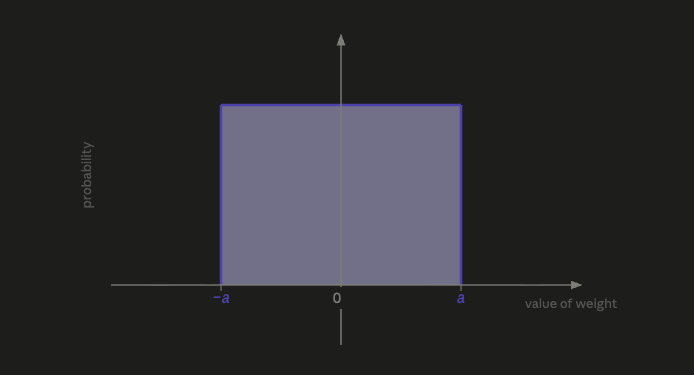

now we'd like to find out what exactly is the probability of each value occuring, i.e. the height of the rectangle on the y axis (probability). this is known as the probability density function (PDF)

we know that the total area under the curve has to be 1 (100% probability).\
$$\text{area of rectangle} = 1$$
$$2a \cdot \text{height} = 1$$
$$\text{probability density function (PDF)} = \frac{1}{2a}$$

so every possible value of a weight has a $\frac{1}{2a}$ chance of being chosen.

we can use this for finding the variance of $W$

$$\text{Var}(W) = E[W^2] - (E[W])^2$$\
the expected mean of our weights is 0, i.e. $E[W] = 0$
$$\therefore \text{Var}(W) = E[W^2]$$
This is a result used frequently here on out, where for a random variable $X$, if the mean/expected value is 0, then $\text{Var}(X) = E[X^2]$

were considering the entire continuous probability distribution ie taking every possible value of $W$ into consideration. so for calculating $E[W^2]$ we integrate over range of the probability distribution $[-a,a]$:
$$\text{Var}(W) = \int_{-a}^{a} w^2 \cdot \left(\text{probability of W occuring}\right) dw$$\
we know that the probability for each value is $\frac{1}{2a}$\
$$\therefore\text{Var}(W) = \int_{-a}^{a} w^2 \left(\frac{1}{2a}\right) dw$$\
$$\text{Var}(W) = \frac{1}{2a} \left[ \frac{w^3}{3} \right]_{-a}^{a}$$\
$$\text{Var}(W) = \frac{1}{2a} \left( \frac{a^3}{3} - \frac{-a^3}{3} \right)$$\
$$\text{Var}(W) = \frac{1}{2a} \left( \frac{2a^3}{3} \right)$$\
$$\text{Var}(W) = \frac{a^2}{3}$$
^Equation 0

we can keep this aside for now

a forward pass of an arbitrary neuron in a linear layer $l$ is given by $z^{(l)} = Wx + b$ for a single input. the whole output of $z^{(l)}$ is:
$$z^{(l)} = \sum_{j=1}^{n_{in}} W_{ij} x_j + b_i$$
$$\therefore \text{Var}(z^{(l)}) = \sum_{j=1}^{n_{in}} \text{Var}(W_{ij} x_j + b_i)$$
adding a constant doesnt affect the variance
$$\therefore \text{Var}(z^{(l)}) = \sum_{j=1}^{n_{in}} \text{Var}(W_{ij} x_j)$$

^Equation 1

note: $i$ is the index of the arbitrary neuron were looking at within our layer. the complete notation of $z^{(l)}$ would be $z_i^{(l)}$ but i use the former for convenience.

consider two independent continuous random variables $X$ and $Y$:
$$E[XY] = \iint xy f_{X,Y}(x,y) dx dy$$\
since they are independent, $f_{X,Y}(x,y) = f_X(x)f_Y(y)$\
\
$$\therefore E[XY] = \iint xy f_X(x)f_Y(y) dx dy = \iint x f_X(x) y f_Y(y) dx dy$$\
this gives us a summation of every possible combination of $X$ and $Y$ while multiplying the probability of each occuring.\
we can now seperate these integrals because $(x_1y_1 + x_1y_2 .... + x_2y_1 + x_2y_2 .... x_ny_n) = (x_1 + x_2 ....)(y_1 + y_2 ...)$\
\
$$\therefore E[XY] = \left( \int x f_X(x) dx \right) \left( \int y f_Y(y) dy \right)$$\
$$E[XY] = E[X]E[Y]$$

we consider $x$, our training data, to be a continuous random variable, just like $W$. the larger the amount of samples, the better it emulates being a continuous random variable.

To get $\text{Var}(Wx)$:
$$\text{Var}(Wx) = E[(Wx)^2] - (E[Wx])^2 = E[(Wx)^2] - (E[W]E[x])^2$$

we know that $E[W] = 0$
$$\therefore \text{Var}(Wx)= E[(Wx)^2] = E[W^2x^2] = E[W^2]E[x^2]$$

^Equation 2

we know that $\text{Var}(W) = E[W^2]$\
^Equation 3

substituting in equation 2:
$$\text{Var}(Wx)= \text{Var}(W) E[x^2]$$
^Equation 4

an effect that we want our initialisations to have is for the outputs $z$ to have a mean of 0. there should be close to an equal number of $z$ on either side of the y axis. the total sum of the magnitudes of the positive $z$ should be close to that of the negative $z$. in that case, $E[z^2]$ will have a non-zero value. looking at the assumptions of symmetrical distribution we have just set, $E[z^2]$ of the negative $z$ should be close to the $E[z^2]$ of the positive $z$.\
but after applying the relu activation, all the negative $z$, ie close to half of the total, are turned to 0. because of this, the variance after the activation is half of what it was before.\
the post activation data is what is fed into the next layer, ie, $x$ of the next layer. therefore we can express $E[x^2]$ using the previous layers' $z$:
$$E[(x^{(l)})^2] = \frac{1}{2} E[(z^{(l-1)})^2]$$
note: the expectation of the squares of all the inputs $x$ of our layer is the same as the expectation of a single arbitrary input's square $(E[(x^{(l)})^2])$ because they all have the same expectation of their squares so we can just take that instead of the expectation of all of them. the same goes for $E[{(z^{(l-1)})}^2]$ as well. the expectation of the square of the output of an arbitrary neuron of the previous layer $l-1$ is the same as the expectation of all of theirs together because theyre all equal

we know that $E[{z^{(l)}}] = 0$,
$$\therefore \text{Var}(z^{(l)}) = E[{(z^{(l)})}^2]$$

meaning:
$$E[(x^{(l)})^2] = \frac{1}{2} \text{Var}(z^{(l-1)})$$

substituting in equation 4:
$$\text{Var}(Wx)= \text{Var}(W) \frac{1}{2} \text{Var}(z^{(l-1)})$$

substituting in equation 1:
$$\text{Var}(z^{(l)}) = \sum_{j=1}^{n_{in}} \text{Var}(W) \frac{1}{2} \text{Var}(z^{(l-1)})$$

$\text{Var}(W)$ and $\text{Var}(z^{(l-1)})$ remain constant for all inputs
$$\therefore \text{Var}(z^{(l)}) = n_{in} \text{Var}(W) \left( \frac{1}{2} \text{Var}(z^{(l-1)}) \right)$$
$$\text{Var}(z^{(l)}) = \frac{1}{2} n_{in} \text{Var}(W) \text{Var}(z^{(l-1)})$$
^Equation 5

suppose every individual layer scales the variance of the previous layer's $z$ by a constant factor $c$:
$$\text{Var}(\text{output z of this layer}) = c \cdot \text{Var}(\text{z of the previous layer})$$
for layer 1 the incoming signal is the initial data $x$:
$$\text{Var}(z^{(1)}) = c \cdot \text{Var}(x)$$\
for layer 2 the incoming signal is the output of layer 1 ($z^{(1)}$):\
\
$$\text{Var}(z^{(2)}) = c \cdot \text{Var}(z^{(1)}) = c \cdot (c \cdot \text{Var}(x)) = c^2 \text{Var}(x)$$
similarly for layer 3:
$$\text{Var}(z^{(3)}) = c \cdot \text{Var}(z^{(2)}) = c \cdot (c^2 \text{Var}(x)) = c^3 \text{Var}(x)$$

meaning we get:
$$\text{Var}(z^{(L)}) = c^L \text{Var}(x)$$
^Equation 6

as we scale and add several layers, $c^L$ tends to explode if $c > 1$ and tends to diminish if $c < 1$.\
this is fixed we we take $c=1$
i.e.$$\text{Var}(z^{(L)}) = \text{Var}(x)$$

substituting in equation 5:

$$\text{Var}(x) = \frac{1}{2} n_{in} \text{Var}(W) \text{Var}(x)$$

$$\frac{1}{2} n_{in} \text{Var}(W) = 1$$
$$\text{Var}(W) = \frac{2}{n_{in}}$$

substituting in equation 0:
$$\frac{2}{n_{in}} = \frac{a^2}{3}$$\
$$a^2 = \frac{6}{n_{in}}$$\
$$a = \sqrt{\frac{6}{n_{in}}}$$

####Model building

In [ ]:
class Linear:
    def __init__(self, in_f, out_f):
        limit = cp.sqrt(6.0 / in_f) #he initialisation
        self.W = cp.random.uniform(-limit, limit, (in_f, out_f))
        self.b = cp.zeros((1, out_f))
        self.dW = cp.zeros_like(self.W)
        self.db = cp.zeros_like(self.b)
        self._x = None

    def forward(self, x):
        self._x = x
        return x @ self.W + self.b

    def backward(self, grad_output):
        self.dW = self._x.T @ grad_output
        self.db = cp.sum(grad_output, axis=0, keepdims=True)  #all the gradients received by backprop are already divided by the total batch size so we add up all of them to get the average
        return grad_output @ self.W.T

class ReLU:
    def __init__(self):
        self._x = None

    def forward(self, x):
        self._x = x
        return cp.maximum(0, x)

    def backward(self, grad_output):
        return grad_output * (self._x > 0)

class Sigmoid:
    def __init__(self):
        self._out = None

    def forward(self, x):
        self._out = 1.0 / (1.0 + cp.exp(-cp.clip(x, -500, 500))) #to avoid having to compute numbers larger than e^500 we cap the values of x at 500
        return self._out

    def backward(self, grad_output):
        return grad_output * self._out * (1.0 - self._out)

class BCELoss:
    def __init__(self, eps=1e-7):
        self.eps = eps
        self._yp = None
        self._yt = None

    def forward(self, y_pred, y_true):
        self._yp = cp.clip(y_pred, self.eps, 1 - self.eps)
        self._yt = y_true
        return -cp.mean(self._yt * cp.log(self._yp) + (1 - self._yt) * cp.log(1 - self._yp))

    def backward(self):
        n = self._yp.shape[0]
        return -(self._yt / self._yp - (1 - self._yt) / (1 - self._yp)) / n

class SGD:
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr

    def step(self):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.W -= self.lr * layer.dW
                layer.b -= self.lr * layer.db

class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

In [ ]:
cp.random.seed(42)

input_dim = X_train_scaled.shape[1]  # 4

model = Network([
    Linear(input_dim, 32), ReLU(),
    Linear(32, 32), ReLU(),
    Linear(32, 32), ReLU(),
    Linear(32, 1),
    Sigmoid()
])

loss_fn = BCELoss()

optimizer = SGD(model.layers, lr=0.001)

####Training

In [ ]:
epochs = 1000
batch_size= 32

for epoch in range(epochs):
    batches = create_batches(X_train_scaled, y_train, batch_size)
    tr_acc= 0
    tr_loss=0

    for X_train_batch, y_train_batch in batches:

      X_train_batch_gpu = cp.array(X_train_batch)
      y_train_batch_gpu = cp.array(y_train_batch)
      y_pred = model.forward(X_train_batch_gpu)
      #we do .item() so that we only pass in the float version. if we directly pass the cupy array then tr_acc becomes a cupy array on the gpu and takes up space so we pass in just the normal version
      ##so that the garbage collector doesnt see a linkage to the outer tr_acc variable and can properly free the gpu space up
      tr_loss += ((X_train_batch.shape[0])*(loss_fn.forward(y_pred, y_train_batch_gpu))).item()

      grad = loss_fn.backward()
      model.backward(grad)

      optimizer.step()

      tr_acc += cp.sum((y_pred > 0.5) == (y_train_batch_gpu > 0.5)).item()

    tr_loss /= X_train_scaled.shape[0]
    tr_acc /= X_train_scaled.shape[0]

    #validation

    val_batches= create_batches(X_val_scaled, y_val, batch_size)
    val_acc= 0
    val_loss=0

    for X_val_batch, y_val_batch in val_batches:
        X_val_batch_gpu = cp.array(X_val_batch)
        y_val_batch_gpu = cp.array(y_val_batch)

        val_pred = model.forward(X_val_batch_gpu)

        val_loss += ((X_val_batch.shape[0])*(loss_fn.forward(val_pred, y_val_batch_gpu))).item()

        val_acc += cp.sum((val_pred > 0.5) == (y_val_batch_gpu > 0.5)).item()

    val_loss /= X_val_scaled.shape[0]
    val_acc /= X_val_scaled.shape[0]

    if (epoch+1)%100 == 0:
      print(f"Epoch {(epoch+1):4d} || Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} || Train Acc: {(100*(tr_acc)):.3f} | Val Acc: {(100*(val_acc)):.3f}")

    if epoch==0:
      best_val_acc= val_acc
      print(f"Current validation accuracy: {(val_acc*100):.4f}%")

    elif best_val_acc<val_acc:
      best_val_acc= val_acc
      print(f"New best validation accuracy at epoch {epoch+1} : {(val_acc*100):.4f}%")

Current validation accuracy: 63.7405%
New best validation accuracy at epoch 2 : 65.6489%
New best validation accuracy at epoch 3 : 67.9389%
New best validation accuracy at epoch 4 : 69.8473%
New best validation accuracy at epoch 5 : 70.9924%
New best validation accuracy at epoch 19 : 71.3740%
New best validation accuracy at epoch 22 : 71.7557%
New best validation accuracy at epoch 27 : 72.1374%
New best validation accuracy at epoch 46 : 72.5191%
New best validation accuracy at epoch 52 : 72.9008%
Epoch  100 || Train Loss: 0.4577 | Val Loss: 0.5321 || Train Acc: 79.465 | Val Acc: 71.756
Epoch  200 || Train Loss: 0.4413 | Val Loss: 0.5131 || Train Acc: 79.656 | Val Acc: 71.374
New best validation accuracy at epoch 285 : 73.2824%
Epoch  300 || Train Loss: 0.4335 | Val Loss: 0.5076 || Train Acc: 80.325 | Val Acc: 73.282
Epoch  400 || Train Loss: 0.4282 | Val Loss: 0.5058 || Train Acc: 81.089 | Val Acc: 73.282
New best validation accuracy at epoch 410 : 73.6641%
Epoch  500 || Train Loss: 0.

model with the best validationaccuracy: 74.8092%

##Using Tanh activation and Xavier initialisation

$\text{Tanh}(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

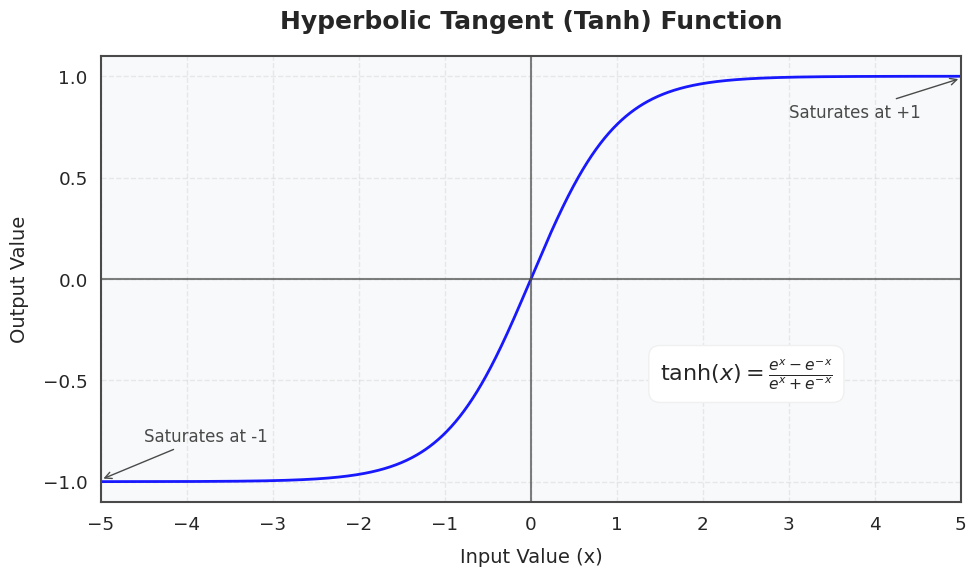

###Xavier (Glorot) Initialisation

Xavier initialisation is used when the input signals for any layer have an expected mean of 0. That is why it is usually not paired with relu activation as all the negative values are converted to 0, making it impossible for the mean to be 0 unless all the other values are also 0.\
We can use tanh activation because that has a mean of 0.\
To find the value of $a$ for our limits $[-a,a]$, we begin by following the same logic we did in the derivation of the limits in He initialisation till we reach Equation 0:
$$\text{Var}(W) = \frac{a^2}{3}$$

Equation 1:
$$\text{Var}(z^{(l)}) = \sum_{j=1}^{n_{in}} \text{Var}(W_{ij} x_j)$$

And Equation 2:
$$\text{Var}(Wx)= E[(Wx)^2] = E[W^2x^2] = E[W^2]E[x^2]$$

This time both $W$ and $x$ have a mean of 0, meaning:
$\text{Var}(x) = E[x^2]$ and $\text{Var}(W) = E[W^2]$

substituting in equation 2:
$$\text{Var}(Wx) = \text{Var}(W)\text{Var}(x)$$

substituting in Equation 1:
$$\therefore \text{Var}(z^{(l)}) = \sum_{j=1}^{n_{in}} \text{Var}(W_{ij} x_j) = \sum_{j=1}^{n_{in}} \text{Var}(W)\text{Var}(x)$$

$\text{Var}(W)$ and $\text{Var}(x)$ remain constant for all the inputs
$$\therefore \text{Var}(z^{(l)}) = n_{in} \text{Var}(W) \text{Var}(x)$$
^Equation 7

suppose every individual layer scales the variance of its incoming signal by the constant factor $c$:
$$\text{Var}(\text{output}) = c \cdot \text{Var}(\text{input})$$
Using the same logic we used to reach equation 6, we get:
$$\text{Var}(z^{(L)}) = c^L \text{Var}(x)$$

and to prevent the explosion/vanishing:
$$\text{Var}(z^{(L)}) = \text{Var}(x)$$

substituting in equation 7:

$$n_{in} \text{Var}(W) = 1$$
$$\text{Var}(W) = \frac{1}{n_{in}}$$

we know that L can be taken as a function of all the outputs of a particular layer:
$$L = f(z_1, z_2, \dots, z_{n_{out}})$$
consider a random starting point in the $L$ vs. $z_i$ graph of L and all the layer ouputs.\
If we take a step parallel to one of the axes $z_m$ by the differential amount $dz_m$ , the ratio of of the change in $L$ to the distance moved parallel to the axis ($dz_m$) is the defenition of the partial differentiation of $L$ wrt $z_m$ because when we move parallel to one of the axes the values of all the other $z$ remain the same.
$$\therefore \text{Change in L} = \frac{\partial L}{\partial z_m} dz_m$$
^Equation 8

if we move in a direction that causes a change of $dz_i$ in all the respective axes, i.e. the movement vector will be $d\vec{z} = d\vec{z}_1 + d\vec{z}_2 + d\vec{z}_3 + \dots + d\vec{z}_n = \langle dz_1, dz_2, dz_3, \dots, dz_n \rangle$
in that case the change in $L$ will then be the sum of all the changes caused by the change in each axis because this is a vector sum of infinitesimal orhtogonal movement on all the axes:
$$\text{the change in L after shifting by } d\vec{z} = dL = \sum_{i=1}^{n} \frac{\partial L}{\partial z_i} dz_i$$
^Equation 9\
this is a concept in multivariate calculus, where the total infinitesimal change in a function $L$ ($dL$) is the sum of the partial differentials wrt all of its intermediate variables.

from this we can also get that
$$dz_i = \sum_{k=1}^{n_{in}} \frac{\partial z_i}{\partial x_k} dx_k$$
since $z_i = g_i(x_1, x_2, \dots, x_{n_{in}})$\
if we take the partial derivative strictly with respect to one input $x_j$, we must hold all other inputs constant. this means the change in all other variables is zero, so we get
$$dz_i = \frac{\partial z_i}{\partial x_j} dx_j$$

substituting in equation 9:
$$dL = \sum_{i=1}^{n_{out}} \frac{\partial L}{\partial z_i} \left( \frac{\partial z_i}{\partial x_j} dx_j \right)$$
$dx_j$ is a differential term independent of the summation index $i$
$$\therefore dL = \left( \sum_{i=1}^{n_{out}} \frac{\partial L}{\partial y_i} \frac{\partial y_i}{\partial x_j} \right) dx_j$$
we know from equation 8 that
$$dL = \frac{\partial L}{\partial x_j} dx_j$$
so we get
$$\Delta x_j = \frac{\partial L}{\partial x_j} = \sum_{i=1}^{n_{out}} \frac{\partial L}{\partial y_i} \frac{\partial y_i}{\partial x_j}$$
^Equation 10

$$\frac{\partial y_i}{\partial x_j} = \frac{\partial}{\partial x_j} \left( \sum_{k=1}^{n_{in}} W_{ik} x_k \right) = W_{ij}$$
substituting in equation 10:
$$\Delta x_j = \sum_{i=1}^{n_{out}} \Delta y_i W_{ij}$$
Taking the variance:
$$\text{Var}(\Delta x_j) = \sum_{i=1}^{n_{out}} \text{Var}(\Delta y_i W_{ij})$$
$$\text{Var}(\Delta x_j) = \sum_{i=1}^{n_{out}} \text{Var}(\Delta y) \text{Var}(W)$$
$$\text{Var}(\Delta x_j) = n_{out} \text{Var}(\Delta y) \text{Var}(W)$$\
working on the same logic as when we reached the conclusion to keep $\text{Var}(z^{(L)}) = \text{Var}(x)$ to prevent the numbers from exploding or vanishing, we come to the conclusion to take $\text{Var}(\Delta x_j) = \text{Var}(\Delta y)$ to prevent explosions/vanishings during backpropagation.

$$\therefore n_{out} \text{Var}(W) = 1$$
$$\text{Var}(W) = \frac{1}{n_{out}}$$

but we had already reached the equation before telling us that $\text{Var}(W) = \frac{1}{n_{in}}$\
since we cant have both, Glorot and Bengio suggested to take the average of the two:
$$\text{Var}(W) = \frac{1}{n_{avg}} = \frac{1}{\frac{n_{in} + n_{out}}{2}} = \frac{2}{n_{in} + n_{out}}$$

substituting in Equation 0:
$$\frac{a^2}{3} = \frac{2}{n_{in} + n_{out}}$$\
$$a^2 = \frac{6}{n_{in} + n_{out}}$$\
$$a = \sqrt{\frac{6}{n_{in} + n_{out}}}$$

###Model Building

In [ ]:
class Linear:
    def __init__(self, in_f, out_f):
        limit = cp.sqrt(6.0 / (in_f + out_f)) #xavier initialisation
        self.W = cp.random.uniform(-limit, limit, (in_f, out_f))
        self.b = cp.zeros((1, out_f))
        self.dW = cp.zeros_like(self.W)
        self.db = cp.zeros_like(self.b)
        self._x = None

    def forward(self, x):
        self._x = x
        return x @ self.W + self.b

    def backward(self, grad_output):
        self.dW = self._x.T @ grad_output
        self.db = cp.sum(grad_output, axis=0, keepdims=True)  #all the gradients received by backprop are already divided by the total batch size so we add up all of them to get the average
        return grad_output @ self.W.T

class Tanh:
    def __init__(self):
        self._x = None

    def forward(self, x):
        self._out = cp.tanh(cp.clip(x, -500, 500))
        return self._out

    def backward(self, grad_output):
        return grad_output * (1.0- ((self._out)**2))

class Sigmoid:
    def __init__(self):
        self._out = None

    def forward(self, x):
        self._out = 1.0 / (1.0 + cp.exp(-cp.clip(x, -500, 500))) #to avoid having to compute numbers larger than e^500 we cap the values of x at 500
        return self._out

    def backward(self, grad_output):
        return grad_output * self._out * (1.0 - self._out)

class BCELoss:
    def __init__(self, eps=1e-7):
        self.eps = eps
        self._yp = None
        self._yt = None

    def forward(self, y_pred, y_true):
        self._yp = cp.clip(y_pred, self.eps, 1 - self.eps)
        self._yt = y_true
        return -cp.mean(self._yt * cp.log(self._yp) + (1 - self._yt) * cp.log(1 - self._yp))

    def backward(self):
        n = self._yp.shape[0]
        return -(self._yt / self._yp - (1 - self._yt) / (1 - self._yp)) / n

class SGD:
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr

    def step(self):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.W -= self.lr * layer.dW
                layer.b -= self.lr * layer.db

class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

In [ ]:
cp.random.seed(42)

input_dim = X_train_scaled.shape[1]  # 4

model_2 = Network([
    Linear(input_dim, 32), Tanh(),
    Linear(32, 32), Tanh(),
    Linear(32, 32), Tanh(),
    Linear(32, 1),
    Sigmoid()
])

loss_fn = BCELoss()

optimizer = SGD(model_2.layers, lr=0.001)

###training

In [ ]:
epochs = 1000
batch_size= 32

for epoch in range(epochs):
    batches = create_batches(X_train_scaled, y_train, batch_size)
    tr_acc= 0
    tr_loss=0

    for X_train_batch, y_train_batch in batches:

      X_train_batch_gpu = cp.array(X_train_batch)
      y_train_batch_gpu = cp.array(y_train_batch)
      y_pred = model_2.forward(X_train_batch_gpu)
      #we do .item() so that we only pass in the float version. if we directly pass the cupy array then tr_acc becomes a cupy array on the gpu and takes up space so we pass in just the normal version
      ##so that the garbage collector doesnt see a linkage to the outer tr_acc variable and can properly free the gpu space up
      tr_loss += ((X_train_batch.shape[0])*(loss_fn.forward(y_pred, y_train_batch_gpu))).item()

      grad = loss_fn.backward()
      model_2.backward(grad)

      optimizer.step()

      tr_acc += cp.sum((y_pred > 0.5) == (y_train_batch_gpu > 0.5)).item()

    tr_loss /= X_train_scaled.shape[0]
    tr_acc /= X_train_scaled.shape[0]

    #validation

    val_batches= create_batches(X_val_scaled, y_val, batch_size)
    val_acc= 0
    val_loss=0

    for X_val_batch, y_val_batch in val_batches:
        X_val_batch_gpu = cp.array(X_val_batch)
        y_val_batch_gpu = cp.array(y_val_batch)

        val_pred = model_2.forward(X_val_batch_gpu)

        val_loss += ((X_val_batch.shape[0])*(loss_fn.forward(val_pred, y_val_batch_gpu))).item()

        val_acc += cp.sum((val_pred > 0.5) == (y_val_batch_gpu > 0.5)).item()

    val_loss /= X_val_scaled.shape[0]
    val_acc /= X_val_scaled.shape[0]

    if (epoch+1)%100 == 0:
      print(f"Epoch {(epoch+1):4d} || Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} || Train Acc: {(100*(tr_acc)):.3f} | Val Acc: {(100*(val_acc)):.3f}")

    if epoch==0:
      best_val_acc= val_acc
      print(f"Current validation accuracy: {(val_acc*100):.4f}%")

    elif best_val_acc<val_acc:
      best_val_acc= val_acc
      print(f"New best validation accuracy at epoch {epoch+1} : {(val_acc*100):.4f}%")

Current validation accuracy: 59.1603%
New best validation accuracy at epoch 2 : 59.9237%
New best validation accuracy at epoch 3 : 63.7405%
New best validation accuracy at epoch 5 : 64.1221%
New best validation accuracy at epoch 6 : 65.2672%
New best validation accuracy at epoch 7 : 65.6489%
New best validation accuracy at epoch 8 : 66.7939%
New best validation accuracy at epoch 9 : 68.7023%
New best validation accuracy at epoch 10 : 69.8473%
New best validation accuracy at epoch 12 : 70.2290%
New best validation accuracy at epoch 13 : 70.6107%
New best validation accuracy at epoch 14 : 70.9924%
New best validation accuracy at epoch 48 : 71.3740%
New best validation accuracy at epoch 87 : 71.7557%
Epoch  100 || Train Loss: 0.4594 | Val Loss: 0.5489 || Train Acc: 79.274 | Val Acc: 71.756
New best validation accuracy at epoch 174 : 72.1374%
Epoch  200 || Train Loss: 0.4543 | Val Loss: 0.5403 || Train Acc: 79.370 | Val Acc: 71.756
Epoch  300 || Train Loss: 0.4516 | Val Loss: 0.5360 || Tra

best validation accuracy: 72.1374%

##Trying out more architectures

###Setup

In [ ]:
class Linear:
    def __init__(self, in_f, out_f):
        limit = cp.sqrt(6.0 / in_f) #he initialisation
        self.W = cp.random.uniform(-limit, limit, (in_f, out_f))
        self.b = cp.zeros((1, out_f))
        self.dW = cp.zeros_like(self.W)
        self.db = cp.zeros_like(self.b)
        self._x = None

    def forward(self, x):
        self._x = x
        return x @ self.W + self.b

    def backward(self, grad_output):
        self.dW = self._x.T @ grad_output
        self.db = cp.sum(grad_output, axis=0, keepdims=True)  #all the gradients received by backprop are already divided by the total batch size so we add up all of them to get the average
        return grad_output @ self.W.T

    def forward(self, x):
        self._x = x
        return x @ self.W + self.b

    def backward(self, grad_output):
        self.dW = self._x.T @ grad_output
        self.db = cp.sum(grad_output, axis=0, keepdims=True)  #all the gradients received by backprop are already divided by the total batch size so we add up all of them to get the average
        return grad_output @ self.W.T

class ReLU:
    def __init__(self):
        self._x = None

    def forward(self, x):
        self._x = x
        return cp.maximum(0, x)

    def backward(self, grad_output):
        return grad_output * (self._x > 0)

class Tanh:
    def __init__(self):
        self._x = None

    def forward(self, x):
        self._out = cp.tanh(cp.clip(x, -500, 500))
        return self._out

    def backward(self, grad_output):
        return grad_output * (1.0- ((self._out)**2))

class Sigmoid:
    def __init__(self):
        self._out = None

    def forward(self, x):
        self._out = 1.0 / (1.0 + cp.exp(-cp.clip(x, -500, 500))) #to avoid having to compute numbers larger than e^500 we cap the values of x at 500
        return self._out

    def backward(self, grad_output):
        return grad_output * self._out * (1.0 - self._out)

class BCELoss:
    def __init__(self, eps=1e-7):
        self.eps = eps
        self._yp = None
        self._yt = None

    def forward(self, y_pred, y_true):
        self._yp = cp.clip(y_pred, self.eps, 1 - self.eps)
        self._yt = y_true
        return -cp.mean(self._yt * cp.log(self._yp) + (1 - self._yt) * cp.log(1 - self._yp))

    def backward(self):
        n = self._yp.shape[0]
        return -(self._yt / self._yp - (1 - self._yt) / (1 - self._yp)) / n

class SGD:
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr

    def step(self):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.W -= self.lr * layer.dW
                layer.b -= self.lr * layer.db

class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

In [ ]:
cp.random.seed(42)

epochs = 1000
batch_size= 32
input_dim = X_train_scaled.shape[1]  # 4

def Train(model, lr=0.001):

  loss_fn = BCELoss()

  optimizer = SGD(model.layers, lr=lr)

  for epoch in range(epochs):
      batches = create_batches(X_train_scaled, y_train, batch_size)
      tr_acc= 0
      tr_loss=0

      for X_train_batch, y_train_batch in batches:

        X_train_batch_gpu = cp.array(X_train_batch)
        y_train_batch_gpu = cp.array(y_train_batch)
        y_pred = model.forward(X_train_batch_gpu)
        #we do .item() so that we only pass in the float version. if we directly pass the cupy array then tr_acc becomes a cupy array on the gpu and takes up space so we pass in just the normal version
        ##so that the garbage collector doesnt see a linkage to the outer tr_acc variable and can properly free the gpu space up
        tr_loss += ((X_train_batch.shape[0])*(loss_fn.forward(y_pred, y_train_batch_gpu))).item()

        grad = loss_fn.backward()
        model.backward(grad)

        optimizer.step()

        tr_acc += cp.sum((y_pred > 0.5) == (y_train_batch_gpu > 0.5)).item()

      tr_loss /= X_train_scaled.shape[0]
      tr_acc /= X_train_scaled.shape[0]

      #validation

      val_batches= create_batches(X_val_scaled, y_val, batch_size)
      val_acc= 0
      val_loss=0

      for X_val_batch, y_val_batch in val_batches:
          X_val_batch_gpu = cp.array(X_val_batch)
          y_val_batch_gpu = cp.array(y_val_batch)

          val_pred = model.forward(X_val_batch_gpu)

          val_loss += ((X_val_batch.shape[0])*(loss_fn.forward(val_pred, y_val_batch_gpu))).item()

          val_acc += cp.sum((val_pred > 0.5) == (y_val_batch_gpu > 0.5)).item()

      val_loss /= X_val_scaled.shape[0]
      val_acc /= X_val_scaled.shape[0]

      if (epoch+1)%100 == 0:
        print(f"Epoch {(epoch+1):4d} || Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} || Train Acc: {(100*(tr_acc)):.3f} | Val Acc: {(100*(val_acc)):.3f}")

      if epoch==0:
        best_val_acc= val_acc
        print(f"Current validation accuracy: {(val_acc*100):.4f}%")

      elif best_val_acc<val_acc:
        best_val_acc= val_acc
        print(f"New best validation accuracy at epoch {epoch+1} : {(val_acc*100):.4f}%")

  return model

###Training

In [ ]:
model_3 = Network([
    Linear(input_dim, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 1),
    Sigmoid()
])

model_3= Train(model_3)

Current validation accuracy: 62.9771%
New best validation accuracy at epoch 2 : 65.2672%
New best validation accuracy at epoch 3 : 66.7939%
New best validation accuracy at epoch 5 : 67.5573%
New best validation accuracy at epoch 9 : 67.9389%
New best validation accuracy at epoch 10 : 68.3206%
New best validation accuracy at epoch 11 : 68.7023%
New best validation accuracy at epoch 16 : 69.0840%
New best validation accuracy at epoch 28 : 69.4656%
New best validation accuracy at epoch 29 : 69.8473%
New best validation accuracy at epoch 43 : 70.2290%
New best validation accuracy at epoch 52 : 70.6107%
New best validation accuracy at epoch 55 : 70.9924%
New best validation accuracy at epoch 75 : 71.3740%
New best validation accuracy at epoch 76 : 71.7557%
New best validation accuracy at epoch 88 : 72.1374%
Epoch  100 || Train Loss: 0.4311 | Val Loss: 0.5222 || Train Acc: 81.471 | Val Acc: 71.756
New best validation accuracy at epoch 139 : 72.5191%
New best validation accuracy at epoch 146 

best val accuracy: 74.0458%

In [ ]:
model_4 = Network([
    Linear(input_dim, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_4= Train(model_4)

Current validation accuracy: 60.3053%
New best validation accuracy at epoch 5 : 60.6870%
New best validation accuracy at epoch 6 : 63.3588%
New best validation accuracy at epoch 7 : 67.9389%
New best validation accuracy at epoch 8 : 70.6107%
New best validation accuracy at epoch 9 : 72.9008%
Epoch  100 || Train Loss: 0.4102 | Val Loss: 0.5162 || Train Acc: 82.330 | Val Acc: 71.374
Epoch  200 || Train Loss: 0.3937 | Val Loss: 0.5114 || Train Acc: 82.713 | Val Acc: 71.756
Epoch  300 || Train Loss: 0.3840 | Val Loss: 0.5131 || Train Acc: 83.381 | Val Acc: 71.756
New best validation accuracy at epoch 381 : 73.2824%
Epoch  400 || Train Loss: 0.3767 | Val Loss: 0.5140 || Train Acc: 83.286 | Val Acc: 73.282
New best validation accuracy at epoch 433 : 74.0458%
Epoch  500 || Train Loss: 0.3699 | Val Loss: 0.5188 || Train Acc: 83.763 | Val Acc: 73.282
Epoch  600 || Train Loss: 0.3649 | Val Loss: 0.5227 || Train Acc: 83.954 | Val Acc: 73.282
New best validation accuracy at epoch 611 : 74.4275%
Ep

best val accuracy: 75.1908%

In [ ]:
model_5 = Network([
    Linear(input_dim, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 1),
    Sigmoid()
])

model_5= Train(model_5)

Current validation accuracy: 40.8397%
New best validation accuracy at epoch 2 : 61.8321%
New best validation accuracy at epoch 3 : 67.1756%
New best validation accuracy at epoch 4 : 67.5573%
New best validation accuracy at epoch 6 : 68.7023%
New best validation accuracy at epoch 7 : 69.0840%
New best validation accuracy at epoch 8 : 69.8473%
New best validation accuracy at epoch 10 : 70.2290%
New best validation accuracy at epoch 11 : 71.3740%
New best validation accuracy at epoch 13 : 71.7557%
New best validation accuracy at epoch 14 : 72.1374%
Epoch  100 || Train Loss: 0.4191 | Val Loss: 0.5281 || Train Acc: 82.713 | Val Acc: 72.137
Epoch  200 || Train Loss: 0.3961 | Val Loss: 0.5317 || Train Acc: 83.190 | Val Acc: 71.756
Epoch  300 || Train Loss: 0.3833 | Val Loss: 0.5301 || Train Acc: 83.477 | Val Acc: 71.756
New best validation accuracy at epoch 343 : 72.5191%
Epoch  400 || Train Loss: 0.3739 | Val Loss: 0.5330 || Train Acc: 83.477 | Val Acc: 71.374
Epoch  500 || Train Loss: 0.366

best val accuracy: 73.2824%

In [ ]:
model_6 = Network([
    Linear(input_dim, 128), ReLU(),
    Linear(128, 128), ReLU(),
    Linear(128, 128), ReLU(),
    Linear(128, 128), ReLU(),
    Linear(128, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_6= Train(model_6)

Current validation accuracy: 66.4122%
New best validation accuracy at epoch 2 : 69.4656%
New best validation accuracy at epoch 3 : 71.3740%
New best validation accuracy at epoch 4 : 71.7557%
New best validation accuracy at epoch 5 : 72.1374%
New best validation accuracy at epoch 12 : 72.5191%
New best validation accuracy at epoch 15 : 72.9008%
New best validation accuracy at epoch 32 : 73.2824%
New best validation accuracy at epoch 38 : 73.6641%
New best validation accuracy at epoch 48 : 74.4275%
New best validation accuracy at epoch 74 : 74.8092%
Epoch  100 || Train Loss: 0.3880 | Val Loss: 0.5164 || Train Acc: 83.095 | Val Acc: 74.046
New best validation accuracy at epoch 166 : 75.1908%
Epoch  200 || Train Loss: 0.3724 | Val Loss: 0.5244 || Train Acc: 84.336 | Val Acc: 72.901
Epoch  300 || Train Loss: 0.3601 | Val Loss: 0.5258 || Train Acc: 84.145 | Val Acc: 74.046
Epoch  400 || Train Loss: 0.3528 | Val Loss: 0.5363 || Train Acc: 85.100 | Val Acc: 71.756
Epoch  500 || Train Loss: 0.3

best validation accuracy: 77.0992%

In [ ]:
model_7 = Network([
    Linear(input_dim, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 128), ReLU(),
    Linear(128, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_7= Train(model_7)

Current validation accuracy: 72.9008%
New best validation accuracy at epoch 2 : 73.6641%
New best validation accuracy at epoch 9 : 74.4275%
New best validation accuracy at epoch 68 : 74.8092%
Epoch  100 || Train Loss: 0.3646 | Val Loss: 0.5359 || Train Acc: 84.145 | Val Acc: 73.282
New best validation accuracy at epoch 180 : 75.1908%
Epoch  200 || Train Loss: 0.3419 | Val Loss: 0.5691 || Train Acc: 85.291 | Val Acc: 73.282
New best validation accuracy at epoch 201 : 75.5725%
New best validation accuracy at epoch 269 : 75.9542%
Epoch  300 || Train Loss: 0.3322 | Val Loss: 0.5706 || Train Acc: 85.864 | Val Acc: 72.519
New best validation accuracy at epoch 388 : 76.7176%
Epoch  400 || Train Loss: 0.3240 | Val Loss: 0.5755 || Train Acc: 86.533 | Val Acc: 71.374
Epoch  500 || Train Loss: 0.3207 | Val Loss: 0.5887 || Train Acc: 86.055 | Val Acc: 73.664
New best validation accuracy at epoch 588 : 78.6260%
Epoch  600 || Train Loss: 0.3131 | Val Loss: 0.5977 || Train Acc: 86.533 | Val Acc: 74.4

best val accuracy: 78.6260%

In [ ]:
model_8 = Network([
    Linear(input_dim, 512), ReLU(),
    Linear(512, 512), ReLU(),
    Linear(512, 512), ReLU(),
    Linear(512, 512), ReLU(),
    Linear(512, 256), ReLU(),
    Linear(256, 128), ReLU(),
    Linear(128, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_8= Train(model_8)

Current validation accuracy: 41.6031%
New best validation accuracy at epoch 2 : 58.0153%
New best validation accuracy at epoch 3 : 69.4656%
New best validation accuracy at epoch 4 : 73.2824%
New best validation accuracy at epoch 5 : 74.0458%
Epoch  100 || Train Loss: 0.3719 | Val Loss: 0.5362 || Train Acc: 84.241 | Val Acc: 71.756
New best validation accuracy at epoch 105 : 74.4275%
Epoch  200 || Train Loss: 0.3464 | Val Loss: 0.5400 || Train Acc: 85.769 | Val Acc: 71.756
New best validation accuracy at epoch 231 : 74.8092%
New best validation accuracy at epoch 274 : 75.5725%
Epoch  300 || Train Loss: 0.3352 | Val Loss: 0.5594 || Train Acc: 85.196 | Val Acc: 73.664
Epoch  400 || Train Loss: 0.3213 | Val Loss: 0.5792 || Train Acc: 86.628 | Val Acc: 73.282
New best validation accuracy at epoch 450 : 76.3359%
New best validation accuracy at epoch 451 : 76.7176%
Epoch  500 || Train Loss: 0.3204 | Val Loss: 0.5904 || Train Acc: 85.960 | Val Acc: 72.519
Epoch  600 || Train Loss: 0.3152 | Val

best accuracy: 76.7176%

In [ ]:
model_9 = Network([
    Linear(input_dim, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 128), ReLU(),
    Linear(128, 128), ReLU(),
    Linear(128, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_9= Train(model_9)

Current validation accuracy: 59.1603%
New best validation accuracy at epoch 3 : 61.4504%
New best validation accuracy at epoch 4 : 62.9771%
New best validation accuracy at epoch 5 : 63.3588%
New best validation accuracy at epoch 6 : 67.5573%
New best validation accuracy at epoch 7 : 70.9924%
New best validation accuracy at epoch 8 : 71.3740%
New best validation accuracy at epoch 9 : 72.1374%
New best validation accuracy at epoch 16 : 72.5191%
New best validation accuracy at epoch 18 : 72.9008%
New best validation accuracy at epoch 22 : 73.6641%
New best validation accuracy at epoch 29 : 75.1908%
Epoch  100 || Train Loss: 0.3475 | Val Loss: 0.5476 || Train Acc: 85.578 | Val Acc: 70.611
New best validation accuracy at epoch 129 : 75.9542%
New best validation accuracy at epoch 166 : 76.3359%
Epoch  200 || Train Loss: 0.3284 | Val Loss: 0.5727 || Train Acc: 86.819 | Val Acc: 71.374
Epoch  300 || Train Loss: 0.3164 | Val Loss: 0.6131 || Train Acc: 86.437 | Val Acc: 74.046
Epoch  400 || Trai

Best validation accuracy: 76.7176%

##Trying out an idea for using both he and xavier initialisations due to a noticed discrepancy

he initialisation assumes that the incoming signals are relu activated but the incoming signals for the very first layer i.e. the training data is not relu activated. its just the z-score normalised training data with a mean of 0. this is more suited to the kind of data that a xavier-initialised layer expects. so ill be running the above experiments with the first layer being xavier initialised and seeing if it makes much of a difference.

###Setup

In [ ]:
class Linear:
    def __init__(self, in_f, out_f):
        limit = cp.sqrt(6.0 / in_f) #he initialisation
        self.W = cp.random.uniform(-limit, limit, (in_f, out_f))
        self.b = cp.zeros((1, out_f))
        self.dW = cp.zeros_like(self.W)
        self.db = cp.zeros_like(self.b)
        self._x = None

    def forward(self, x):
        self._x = x
        return x @ self.W + self.b

    def backward(self, grad_output):
        self.dW = self._x.T @ grad_output
        self.db = cp.sum(grad_output, axis=0, keepdims=True)  #all the gradients received by backprop are already divided by the total batch size so we add up all of them to get the average
        return grad_output @ self.W.T

class Xavier_Linear:
    def __init__(self, in_f, out_f):
        limit = cp.sqrt(6.0 / (in_f + out_f)) #xavier initialisation
        self.W = cp.random.uniform(-limit, limit, (in_f, out_f))
        self.b = cp.zeros((1, out_f))
        self.dW = cp.zeros_like(self.W)
        self.db = cp.zeros_like(self.b)
        self._x = None

    def forward(self, x):
        self._x = x
        return x @ self.W + self.b

    def backward(self, grad_output):
        self.dW = self._x.T @ grad_output
        self.db = cp.sum(grad_output, axis=0, keepdims=True)  #all the gradients received by backprop are already divided by the total batch size so we add up all of them to get the average
        return grad_output @ self.W.T

class ReLU:
    def __init__(self):
        self._x = None

    def forward(self, x):
        self._x = x
        return cp.maximum(0, x)

    def backward(self, grad_output):
        return grad_output * (self._x > 0)

class Tanh:
    def __init__(self):
        self._x = None

    def forward(self, x):
        self._out = cp.tanh(cp.clip(x, -500, 500))
        return self._out

    def backward(self, grad_output):
        return grad_output * (1.0- ((self._out)**2))

class Sigmoid:
    def __init__(self):
        self._out = None

    def forward(self, x):
        self._out = 1.0 / (1.0 + cp.exp(-cp.clip(x, -500, 500))) #to avoid having to compute numbers larger than e^500 we cap the values of x at 500
        return self._out

    def backward(self, grad_output):
        return grad_output * self._out * (1.0 - self._out)

class BCELoss:
    def __init__(self, eps=1e-7):
        self.eps = eps
        self._yp = None
        self._yt = None

    def forward(self, y_pred, y_true):
        self._yp = cp.clip(y_pred, self.eps, 1 - self.eps)
        self._yt = y_true
        return -cp.mean(self._yt * cp.log(self._yp) + (1 - self._yt) * cp.log(1 - self._yp))

    def backward(self):
        n = self._yp.shape[0]
        return -(self._yt / self._yp - (1 - self._yt) / (1 - self._yp)) / n

class SGD:
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr

    def step(self):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.W -= self.lr * layer.dW
                layer.b -= self.lr * layer.db

class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

In [ ]:
cp.random.seed(42)

epochs = 1000
batch_size= 32
input_dim = X_train_scaled.shape[1]  # 4

def Train(model, lr=0.001):

  loss_fn = BCELoss()

  optimizer = SGD(model.layers, lr=lr)

  for epoch in range(epochs):
      batches = create_batches(X_train_scaled, y_train, batch_size)
      tr_acc= 0
      tr_loss=0

      for X_train_batch, y_train_batch in batches:

        X_train_batch_gpu = cp.array(X_train_batch)
        y_train_batch_gpu = cp.array(y_train_batch)
        y_pred = model.forward(X_train_batch_gpu)
        #we do .item() so that we only pass in the float version. if we directly pass the cupy array then tr_acc becomes a cupy array on the gpu and takes up space so we pass in just the normal version
        ##so that the garbage collector doesnt see a linkage to the outer tr_acc variable and can properly free the gpu space up
        tr_loss += ((X_train_batch.shape[0])*(loss_fn.forward(y_pred, y_train_batch_gpu))).item()

        grad = loss_fn.backward()
        model.backward(grad)

        optimizer.step()

        tr_acc += cp.sum((y_pred > 0.5) == (y_train_batch_gpu > 0.5)).item()

      tr_loss /= X_train_scaled.shape[0]
      tr_acc /= X_train_scaled.shape[0]

      #validation

      val_batches= create_batches(X_val_scaled, y_val, batch_size)
      val_acc= 0
      val_loss=0

      for X_val_batch, y_val_batch in val_batches:
          X_val_batch_gpu = cp.array(X_val_batch)
          y_val_batch_gpu = cp.array(y_val_batch)

          val_pred = model.forward(X_val_batch_gpu)

          val_loss += ((X_val_batch.shape[0])*(loss_fn.forward(val_pred, y_val_batch_gpu))).item()

          val_acc += cp.sum((val_pred > 0.5) == (y_val_batch_gpu > 0.5)).item()

      val_loss /= X_val_scaled.shape[0]
      val_acc /= X_val_scaled.shape[0]

      if (epoch+1)%100 == 0:
        print(f"Epoch {(epoch+1):4d} || Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} || Train Acc: {(100*(tr_acc)):.3f} | Val Acc: {(100*(val_acc)):.3f}")

      if epoch==0:
        best_val_acc= val_acc
        print(f"Current validation accuracy: {(val_acc*100):.4f}%")

      elif best_val_acc<val_acc:
        best_val_acc= val_acc
        print(f"New best validation accuracy at epoch {epoch+1} : {(val_acc*100):.4f}%")

  return model

###Training

In [ ]:
model_3_alt = Network([
    Xavier_Linear(input_dim, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 1),
    Sigmoid()
])

model_3_alt= Train(model_3_alt)

Current validation accuracy: 62.9771%
New best validation accuracy at epoch 3 : 63.7405%
New best validation accuracy at epoch 22 : 64.1221%
New best validation accuracy at epoch 35 : 64.5038%
New best validation accuracy at epoch 42 : 64.8855%
New best validation accuracy at epoch 44 : 65.2672%
New best validation accuracy at epoch 46 : 65.6489%
New best validation accuracy at epoch 48 : 66.0305%
New best validation accuracy at epoch 50 : 66.4122%
New best validation accuracy at epoch 51 : 66.7939%
New best validation accuracy at epoch 57 : 67.1756%
New best validation accuracy at epoch 59 : 67.9389%
New best validation accuracy at epoch 72 : 68.3206%
New best validation accuracy at epoch 74 : 68.7023%
Epoch  100 || Train Loss: 0.5006 | Val Loss: 0.5683 || Train Acc: 78.701 | Val Acc: 69.084
New best validation accuracy at epoch 100 : 69.0840%
New best validation accuracy at epoch 102 : 69.4656%
New best validation accuracy at epoch 106 : 69.8473%
New best validation accuracy at epoch

alt: 74.0458% vs. og: 74.0458%

In [ ]:
model_4_alt = Network([
    Xavier_Linear(input_dim, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_4_alt= Train(model_4_alt)

Current validation accuracy: 58.7786%
New best validation accuracy at epoch 19 : 59.5420%
New best validation accuracy at epoch 20 : 59.9237%
New best validation accuracy at epoch 22 : 61.0687%
New best validation accuracy at epoch 23 : 61.4504%
New best validation accuracy at epoch 24 : 61.8321%
New best validation accuracy at epoch 25 : 62.2137%
New best validation accuracy at epoch 27 : 62.5954%
New best validation accuracy at epoch 29 : 63.3588%
New best validation accuracy at epoch 34 : 63.7405%
New best validation accuracy at epoch 35 : 64.5038%
New best validation accuracy at epoch 36 : 64.8855%
New best validation accuracy at epoch 37 : 65.2672%
New best validation accuracy at epoch 39 : 65.6489%
New best validation accuracy at epoch 41 : 66.4122%
New best validation accuracy at epoch 44 : 66.7939%
New best validation accuracy at epoch 53 : 67.1756%
New best validation accuracy at epoch 54 : 67.5573%
New best validation accuracy at epoch 58 : 67.9389%
New best validation accura

alt: 74.8092% vs. og: 75.1908%

In [ ]:
model_5_alt = Network([
    Xavier_Linear(input_dim, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 1),
    Sigmoid()
])

model_5_alt= Train(model_5_alt)

Current validation accuracy: 43.8931%
New best validation accuracy at epoch 2 : 46.5649%
New best validation accuracy at epoch 3 : 48.0916%
New best validation accuracy at epoch 4 : 62.2137%
New best validation accuracy at epoch 5 : 66.0305%
New best validation accuracy at epoch 6 : 69.0840%
New best validation accuracy at epoch 7 : 71.3740%
New best validation accuracy at epoch 9 : 71.7557%
New best validation accuracy at epoch 10 : 73.6641%
New best validation accuracy at epoch 11 : 74.0458%
New best validation accuracy at epoch 13 : 75.1908%
New best validation accuracy at epoch 14 : 75.5725%
New best validation accuracy at epoch 17 : 76.7176%
New best validation accuracy at epoch 26 : 77.0992%
New best validation accuracy at epoch 33 : 77.4809%
New best validation accuracy at epoch 35 : 77.8626%
New best validation accuracy at epoch 50 : 78.2443%
Epoch  100 || Train Loss: 0.4392 | Val Loss: 0.4993 || Train Acc: 82.426 | Val Acc: 73.664
Epoch  200 || Train Loss: 0.4246 | Val Loss: 0

alt: 78.2443% vs. og: 73.2824%

In [ ]:
model_6_alt = Network([
    Xavier_Linear(input_dim, 128), ReLU(),
    Linear(128, 128), ReLU(),
    Linear(128, 128), ReLU(),
    Linear(128, 128), ReLU(),
    Linear(128, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_6_alt= Train(model_6_alt)

Current validation accuracy: 59.1603%
New best validation accuracy at epoch 13 : 59.9237%
New best validation accuracy at epoch 16 : 60.6870%
New best validation accuracy at epoch 17 : 62.2137%
New best validation accuracy at epoch 18 : 62.5954%
New best validation accuracy at epoch 20 : 63.3588%
New best validation accuracy at epoch 21 : 64.1221%
New best validation accuracy at epoch 22 : 64.5038%
New best validation accuracy at epoch 23 : 66.0305%
New best validation accuracy at epoch 25 : 67.1756%
New best validation accuracy at epoch 26 : 68.7023%
New best validation accuracy at epoch 27 : 69.8473%
New best validation accuracy at epoch 29 : 71.3740%
New best validation accuracy at epoch 30 : 72.1374%
New best validation accuracy at epoch 31 : 72.5191%
New best validation accuracy at epoch 32 : 72.9008%
New best validation accuracy at epoch 33 : 73.2824%
New best validation accuracy at epoch 34 : 74.4275%
Epoch  100 || Train Loss: 0.4563 | Val Loss: 0.5586 || Train Acc: 80.420 | Val

alt: 74.4275% vs. og: 77.0992%

In [ ]:
model_7_alt = Network([
    Xavier_Linear(input_dim, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 128), ReLU(),
    Linear(128, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_7_alt= Train(model_7_alt)

Current validation accuracy: 40.8397%
New best validation accuracy at epoch 3 : 46.9466%
New best validation accuracy at epoch 4 : 62.5954%
New best validation accuracy at epoch 5 : 67.1756%
New best validation accuracy at epoch 6 : 69.0840%
New best validation accuracy at epoch 7 : 70.9924%
New best validation accuracy at epoch 8 : 71.3740%
New best validation accuracy at epoch 10 : 71.7557%
Epoch  100 || Train Loss: 0.4577 | Val Loss: 0.5249 || Train Acc: 80.707 | Val Acc: 71.374
New best validation accuracy at epoch 141 : 72.1374%
New best validation accuracy at epoch 161 : 72.5191%
New best validation accuracy at epoch 166 : 72.9008%
New best validation accuracy at epoch 182 : 73.6641%
Epoch  200 || Train Loss: 0.4186 | Val Loss: 0.5037 || Train Acc: 82.808 | Val Acc: 73.664
New best validation accuracy at epoch 202 : 74.0458%
New best validation accuracy at epoch 278 : 74.8092%
Epoch  300 || Train Loss: 0.4041 | Val Loss: 0.5074 || Train Acc: 82.999 | Val Acc: 73.664
New best vali

alt:75.1908% vs. og: 78.6260%

In [ ]:
model_8_alt = Network([
    Xavier_Linear(input_dim, 512), ReLU(),
    Linear(512, 512), ReLU(),
    Linear(512, 512), ReLU(),
    Linear(512, 512), ReLU(),
    Linear(512, 256), ReLU(),
    Linear(256, 128), ReLU(),
    Linear(128, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_8_alt= Train(model_8_alt)

Current validation accuracy: 59.1603%
New best validation accuracy at epoch 11 : 61.0687%
New best validation accuracy at epoch 12 : 61.4504%
New best validation accuracy at epoch 13 : 62.9771%
New best validation accuracy at epoch 14 : 64.5038%
New best validation accuracy at epoch 15 : 64.8855%
New best validation accuracy at epoch 16 : 65.2672%
New best validation accuracy at epoch 19 : 66.4122%
New best validation accuracy at epoch 20 : 67.5573%
New best validation accuracy at epoch 21 : 69.0840%
New best validation accuracy at epoch 22 : 69.8473%
New best validation accuracy at epoch 25 : 70.6107%
New best validation accuracy at epoch 26 : 71.3740%
New best validation accuracy at epoch 28 : 71.7557%
New best validation accuracy at epoch 29 : 72.1374%
New best validation accuracy at epoch 30 : 72.9008%
New best validation accuracy at epoch 31 : 75.1908%
New best validation accuracy at epoch 32 : 75.5725%
Epoch  100 || Train Loss: 0.4396 | Val Loss: 0.5365 || Train Acc: 82.235 | Val

alt: 75.5725% vs. og: 76.7176%

In [ ]:
model_9_alt = Network([
    Xavier_Linear(input_dim, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 256), ReLU(),
    Linear(256, 128), ReLU(),
    Linear(128, 128), ReLU(),
    Linear(128, 64), ReLU(),
    Linear(64, 64), ReLU(),
    Linear(64, 32), ReLU(),
    Linear(32, 32), ReLU(),
    Linear(32, 16), ReLU(),
    Linear(16, 16), ReLU(),
    Linear(16, 1),
    Sigmoid()
])

model_9_alt= Train(model_9_alt)

Current validation accuracy: 59.1603%
New best validation accuracy at epoch 9 : 59.5420%
New best validation accuracy at epoch 11 : 60.3053%
New best validation accuracy at epoch 12 : 60.6870%
New best validation accuracy at epoch 13 : 63.7405%
New best validation accuracy at epoch 14 : 68.7023%
New best validation accuracy at epoch 22 : 69.0840%
New best validation accuracy at epoch 23 : 69.4656%
New best validation accuracy at epoch 25 : 69.8473%
New best validation accuracy at epoch 26 : 70.2290%
New best validation accuracy at epoch 27 : 70.6107%
New best validation accuracy at epoch 31 : 70.9924%
New best validation accuracy at epoch 42 : 71.3740%
New best validation accuracy at epoch 49 : 71.7557%
New best validation accuracy at epoch 52 : 72.1374%
New best validation accuracy at epoch 54 : 72.5191%
New best validation accuracy at epoch 57 : 72.9008%
New best validation accuracy at epoch 67 : 73.2824%
New best validation accuracy at epoch 68 : 73.6641%
Epoch  100 || Train Loss: 0

alt: 77.0992% vs. og: 76.7176%

###Result

doesnt seem to make much of a difference on an average. we can take a look at what exactly happens when we use he initialisation for the first layer as well:

$$\text{Var}(z^{(l)}) = n_{in} \text{Var}(W) \text{Var}(x^{(l)}) = n_{in} \text{Var}(W) \left( \frac{1}{2} \text{Var}(z^{(l-1)}) \right)$$
we have seen before that we must keep $\text{Var}(z^{(l)}) = \text{Var}(z^{(l-1)})$
$$\therefore 1 = n_{in} \text{Var}(W) \left( \frac{1}{2} \right)$$\
So we set  $\text{Var}(W) = \frac{2}{n_{in}}$, having to keep 2 at the numerator to balance out $\frac{1}{2}$ brought by the halved variance.

But for our initial layer $l=1$, the incoming signal is the non-relu activated z-score normalised training data which has a variance of 1 that isnt halved:
$$\text{Var}(z^{(1)}) = n_{in} \cdot \frac{2}{n_{in}} \cdot \text{Var}(x) = n_{in} \cdot \frac{2}{n_{in}} \cdot 1 = 2$$

meaning instead of keeping the expected variance of the outputs of the layer at 1, it keeps it at 2.\
considering that this discrepancy is present only in the first layer and none of the others, it makes sense that it doesnt cause that much of a difference.